### PTID-AIE-JUN-26-11116 and project ID is PRCP-1006 - Home Loan Default-Risk Management

### Home Loan Defaulter Risk Management Project

In [ ]:
!pip install matplotlib

In [ ]:
!pip install seaborn

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv("/content/application_train.csv")

In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [9]:
print(f"Shape: {df.shape}")

Shape: (307511, 122)


In [10]:
print(f"Missing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values (top 10):
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64


In [11]:
column_dict = {col: df[col].tolist() for col in df.columns}

In [12]:
print(column_dict.keys())

dict_keys(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_

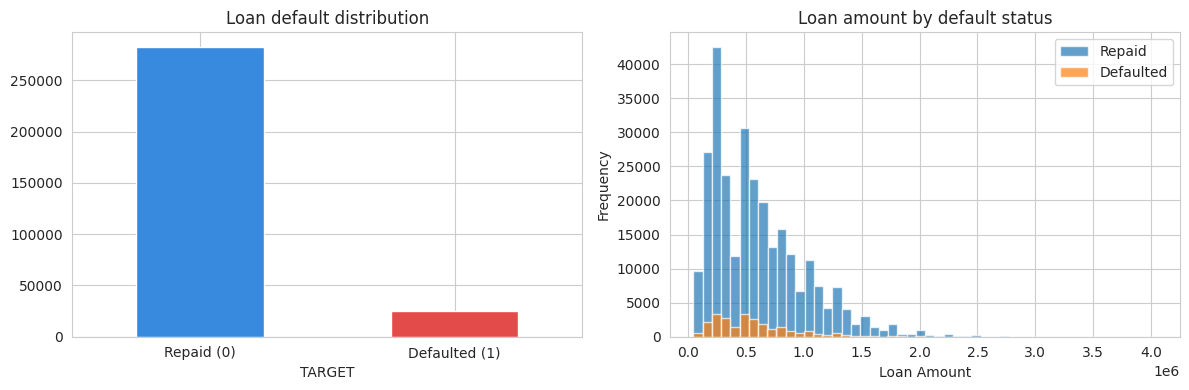

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['TARGET'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color=['#378ADD', '#E24B4A']
)

axes[0].set_title('Loan default distribution')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(
    ['Repaid (0)', 'Defaulted (1)'],
    rotation=0
)

# Loan amount by default status
axes[1].hist(
    df[df['TARGET'] == 0]['AMT_CREDIT'],
    bins=50,
    alpha=0.7,
    label='Repaid'
)

axes[1].hist(
    df[df['TARGET'] == 1]['AMT_CREDIT'],
    bins=50,
    alpha=0.7,
    label='Defaulted'
)

axes[1].set_title('Loan amount by default status')
axes[1].set_xlabel('Loan Amount')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

This indicates a highly imbalanced classification problem.

In [14]:
df_copy = df.copy(deep=True)

In [15]:
df_copy.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
df_copy.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [17]:
bureau = pd.read_csv("/content/bureau.csv")

In [18]:
bureau_balance = pd.read_csv("/content/bureau_balance.csv")

In [19]:
prev_application = pd.read_csv("/content/previous_application.csv")

In [20]:
pos = pd.read_csv("/content/POS_CASH_balance.csv")

In [21]:
cc_balance = pd.read_csv("/content/credit_card_balance.csv")

In [22]:
inst_payments = pd.read_csv("/content/installments_payments.csv")

#### Aggregate the bureau_balance using SK_ID_BUREAU

In [23]:
bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE':['min','max','count']
})

bureau_balance_agg.columns = ['BB_MIN_MONTH',
                  'BB_MAX_MONTH',
                  'BB_MONTH_COUNT']

bureau_balance_agg = bureau_balance_agg.reset_index()

Merge to Bureau

In [24]:
bureau = bureau.merge(
    bureau_balance_agg,
    on='SK_ID_BUREAU',
    how='left'
)

Aggregate bureau by customer

In [25]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU':'count',
    'AMT_CREDIT_SUM':['sum','mean'],
    'AMT_CREDIT_SUM_DEBT':['sum','mean'],
    'CREDIT_DAY_OVERDUE':['max','sum'],
    'BB_MONTH_COUNT':'mean'
})

bureau_agg.columns = [
    'BUREAU_LOAN_COUNT',
    'BUREAU_CREDIT_SUM',
    'BUREAU_CREDIT_MEAN',
    'BUREAU_DEBT_SUM',
    'BUREAU_DEBT_MEAN',
    'MAX_OVERDUE',
    'TOTAL_OVERDUE',
    'AVG_BB_MONTHS'
]

bureau_agg = bureau_agg.reset_index()


Aggregate Previous Application

In [26]:
prev_agg = prev_application.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV':'count',
    'AMT_APPLICATION':['sum','mean'],
    'AMT_CREDIT':['sum','mean']
})

prev_agg.columns = [
    'PREV_APP_COUNT',
    'PREV_APP_AMT_SUM',
    'PREV_APP_AMT_MEAN',
    'PREV_CREDIT_SUM',
    'PREV_CREDIT_MEAN'
]

prev_agg = prev_agg.reset_index()

Aggregate POS_CASH_Balance

In [27]:
pos_agg = pos.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV':'nunique',
    'MONTHS_BALANCE':['min','max'],
    'CNT_INSTALMENT_FUTURE':'mean'
})

pos_agg.columns = [
    'POS_LOAN_COUNT',
    'POS_MIN_MONTH',
    'POS_MAX_MONTH',
    'POS_FUTURE_INST_MEAN'
]

pos_agg = pos_agg.reset_index()

Aggregate Credit Card Balance

In [28]:
cc_agg = cc_balance.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE':['mean','max'],
    'AMT_CREDIT_LIMIT_ACTUAL':['mean'],
    'SK_ID_PREV':'nunique'
})

cc_agg.columns = [
    'CC_BALANCE_MEAN',
    'CC_BALANCE_MAX',
    'CC_LIMIT_MEAN',
    'CC_CARD_COUNT'
]

cc_agg = cc_agg.reset_index()

Aggregate Installment Payments

In [29]:
inst_payments['PAYMENT_DIFF'] = (
    inst_payments['AMT_PAYMENT'] -
    inst_payments['AMT_INSTALMENT']
)

inst_payments['DAYS_DELAY'] = (
    inst_payments['DAYS_ENTRY_PAYMENT'] -
    inst_payments['DAYS_INSTALMENT']
)

inst_agg = inst_payments.groupby('SK_ID_CURR').agg({
    'PAYMENT_DIFF':['mean','min','max'],
    'DAYS_DELAY':['mean','max'],
    'AMT_PAYMENT':['sum','mean']
})

inst_agg.columns = [
    'PAY_DIFF_MEAN',
    'PAY_DIFF_MIN',
    'PAY_DIFF_MAX',
    'DELAY_MEAN',
    'DELAY_MAX',
    'TOTAL_PAYMENT',
    'AVG_PAYMENT'
]

inst_agg = inst_agg.reset_index()

Merge Everything into One Dataset

In [30]:
final_df = df_copy.copy()

final_df = final_df.merge(
    bureau_agg,
    on='SK_ID_CURR',
    how='left'
)

final_df = final_df.merge(
    prev_agg,
    on='SK_ID_CURR',
    how='left'
)

final_df = final_df.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)

final_df = final_df.merge(
    cc_agg,
    on='SK_ID_CURR',
    how='left'
)

final_df = final_df.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

In [31]:
print(final_df.shape)

(307511, 150)


In [32]:
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_BALANCE_MAX,CC_LIMIT_MEAN,CC_CARD_COUNT,PAY_DIFF_MEAN,PAY_DIFF_MIN,PAY_DIFF_MAX,DELAY_MEAN,DELAY_MAX,TOTAL_PAYMENT,AVG_PAYMENT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,0.000000,0.000,0.0,-20.421053,-12.0,219625.695,11559.247105
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,0.000000,0.000,0.0,-7.160000,-1.0,1618864.650,64754.586000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,0.000000,0.000,0.0,-7.666667,-3.0,21288.465,7096.155000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,270000.0,1.0,0.000000,0.000,0.0,-19.375000,-1.0,1007153.415,62947.088438
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,-452.384318,-22655.655,0.0,-3.636364,12.0,806127.975,12214.060227


In [33]:
final_df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_BALANCE_MAX,CC_LIMIT_MEAN,CC_CARD_COUNT,PAY_DIFF_MEAN,PAY_DIFF_MIN,PAY_DIFF_MAX,DELAY_MEAN,DELAY_MAX,TOTAL_PAYMENT,AVG_PAYMENT
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### EDA

In [34]:
target_counts = df_copy['TARGET'].value_counts()
target_percentage = df_copy['TARGET'].value_counts(normalize=True)*100

print(target_counts)
print(target_percentage)

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


Default Rate Analysis
Default rate = [Number of defaulters/Total customers]*100

#### Univariate Analysis of TARGET

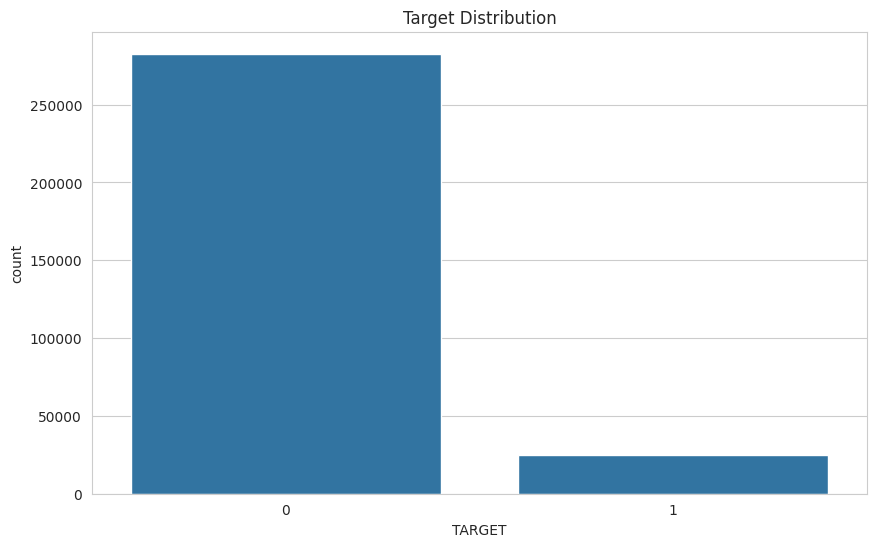

In [35]:
sns.countplot(x='TARGET', data=df_copy)
plt.title("Target Distribution")
plt.show()

8.07% Defaulters
91.93% Non-defaulters
Class imbalance exists

In [36]:
df_copy['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


In [37]:
(df_copy['CODE_GENDER'].value_counts(normalize=True) * 100).round(2)

,proportion
CODE_GENDER,
F,65.83
M,34.16
XNA,0.00


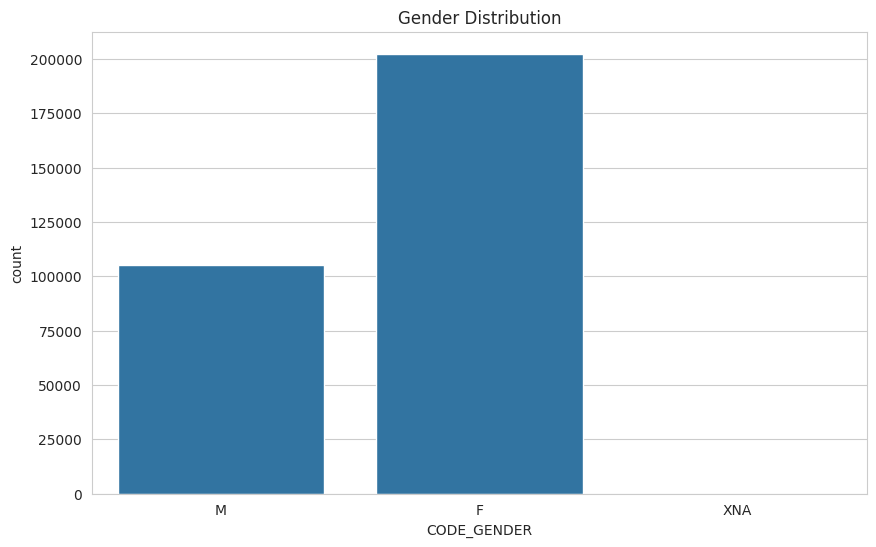

In [38]:
sns.countplot(x='CODE_GENDER', data=df_copy)
plt.title("Gender Distribution")
plt.show()

Female applicants constitute approximately 66% of the dataset.
Male applicants account for approximately 34%.

In [39]:
df_copy['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,158774
Commercial associate,71617
Pensioner,55362
State servant,21703
Unemployed,22
Student,18
Businessman,10
Maternity leave,5


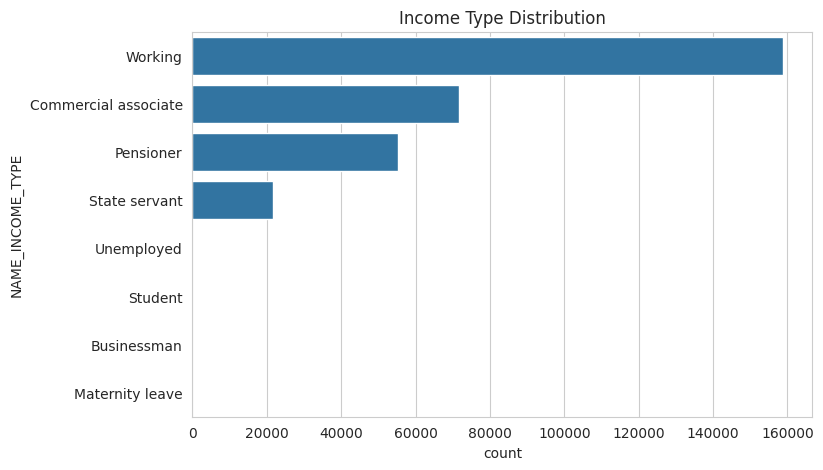

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='NAME_INCOME_TYPE',
    data=df_copy,
    order=df_copy['NAME_INCOME_TYPE'].value_counts().index
)

plt.title("Income Type Distribution")
plt.show()

In [41]:
df_copy['AMT_INCOME_TOTAL'].describe()

,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


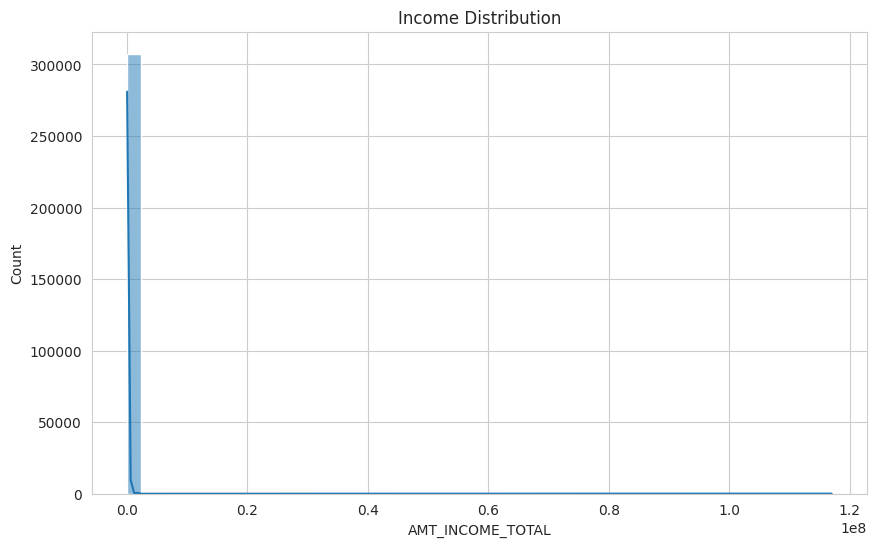

In [42]:
sns.histplot(
    df_copy['AMT_INCOME_TOTAL'],
    bins=50,
    kde=True
)

plt.title("Income Distribution")
plt.show()

The distribution is positively right skewed.

25% of applicants earn less than 112,500.
50% earn less than 147,150.
75% earn less than 202,500.

Most applicants are concentrated in a relatively narrow income range, while a few very high-income observations create a long right tail.

In [43]:
df_copy['AGE_YEARS'] = (
    abs(df_copy['DAYS_BIRTH']) / 365
)

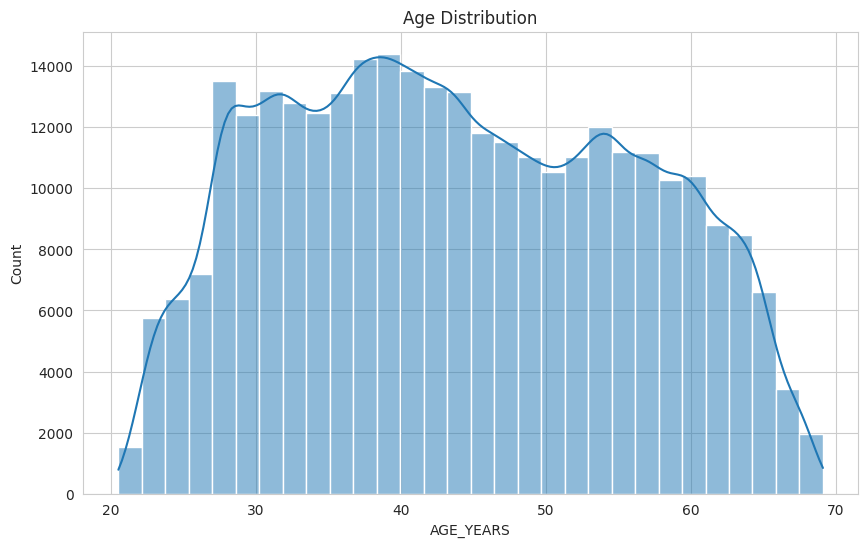

In [44]:
sns.histplot(
    df_copy['AGE_YEARS'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

In [45]:
df_copy['DAYS_EMPLOYED']

,DAYS_EMPLOYED
0,-637
1,-1188
2,-225
3,-3039
4,-3038
...,...
307506,-236
307507,365243
307508,-7921
307509,-4786


In [46]:
(df_copy['DAYS_EMPLOYED'] == 365243).sum()

np.int64(55374)

In [47]:
55374 / len(df_copy) * 100

18.00716071945394

So nearly 18% of applicants have this special value.
Missing employment information or A special code for applicants who are not conventionally employed (often pensioners)  

In [48]:
default_rate = df_copy['TARGET'].mean()*100
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 8.07%


- A Default Rate of 8.07% means that approximately 8 out of every 100 customers in the dataset experienced payment difficulties or defaulted on their loan obligations.
- Loan portfolio is good because 90% of the customers are non-defaulters.
- The dataset is imbalanced.

In [49]:
df_copy.groupby('CODE_GENDER')['TARGET'].mean()*100

,TARGET
CODE_GENDER,
F,6.999328
M,10.141920
XNA,0.000000


Female Applicants
- Default rate:  6.999328%
- Lower than the overall portfolio default rate (8.07%).
- Indicates females in this dataset are relatively lower-risk borrowers.
  
Male Applicants
        - Default rate: 10.141920%
        Higher than both:
           - Overall default rate (8.07%)
           -  Female default rate (6.999328%)
        Suggests male applicants exhibit a stronger tendency to default.
This suggests that gender is associated with repayment behavior in the dataset.

In [50]:
df_copy.groupby('NAME_INCOME_TYPE')['TARGET'].mean()*100

,TARGET
NAME_INCOME_TYPE,
Businessman,0.000000
Commercial associate,7.484257
Maternity leave,40.000000
Pensioner,5.386366
State servant,5.754965
Student,0.000000
Unemployed,36.363636
Working,9.588472


This analysis shows how the default rate varies across income source categories, which is highly relevant in credit risk modeling because income stability often influences repayment behavior.

##### Low-Risk Segments

Pensioners (5.38%)
- Lowest meaningful default rate among major groups.
- Pension income is generally stable and predictable.
- Indicates relatively lower credit risk.
  
State Servants (5.75%)
- Government employees often have stable employment and income.
- Lower default rate compared with the overall portfolio (8.07%).

Commercial Associates (7.48%)
- Slightly below the overall default rate.
- Moderate-risk segment.

##### Higher-Risk Segments

Working (9.58%)
- Largest customer segment in most Home Credit datasets.
- Default rate exceeds the overall portfolio average (8.13%).
- Suggests salaried workers are not necessarily the safest borrowers.

Unemployed (36.36%)
- Extremely high default rate.
- More than four times the portfolio average.

Default rate analysis by income type reveals significant variation across customer segments. Pensioners (5.38%) and state servants (5.75%) exhibit the lowest default rates among major groups, indicating lower credit risk. In contrast, working applicants have a higher-than-average default rate (9.58%), while unemployed applicants (36.36%) and Maternity leave (40%) exhibit substantially elevated default risk. Categories such as businessmen and students show 0% default rates, but have very few observations and should be interpreted with caution. These findings suggest that income source is a potentially important predictor of loan default.

In [51]:
df_copy['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,158774
Commercial associate,71617
Pensioner,55362
State servant,21703
Unemployed,22
Student,18
Businessman,10
Maternity leave,5


In [52]:
df_copy.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()*100

,TARGET
NAME_EDUCATION_TYPE,
Academic degree,1.829268
Higher education,5.355115
Incomplete higher,8.484966
Lower secondary,10.927673
Secondary / secondary special,8.939929


The above output shows the default rate by education level, which is an important factor in credit risk assessment.

##### Lowest-Risk Segments

Academic Degree (1.829%)
- Lowest default rate among all education groups.
- Indicates that highly educated applicants tend to have stronger repayment behavior.
- May reflect higher income levels, better employment opportunities, and greater financial stability.

Higher Education (5.35%)
- Significantly below the portfolio average (8.07%).
- Suggests a clear relationship between higher educational attainment and lower credit risk.

#### Medium-Risk Segments

Incomplete Higher Education (8.48%)
- Slightly above the overall default rate.
- Risk level increases compared to applicants who completed higher education.

Secondary / Secondary Special (8.93%)
- One of the largest groups in the dataset.
- Default rate is above the portfolio average.
- Indicates moderate credit risk.

#### Highest-Risk Segment
Lower Secondary (10.92%)
- Highest default rate among education categories.
- Approximately twice the default rate of applicants with higher education.

As educational attainment decreases, default rates tend to increase.
Default rate analysis by education level reveals a strong negative relationship between educational attainment and loan default.
This suggests that education level may serve as an important predictor in the loan default model.

#### Missing Percentage

In [53]:
missing_values = df_copy.isnull().sum()

print(missing_values)

missing_percent = (
    missing_values / len(df_copy)
    * 100
).sort_values(ascending=False)


missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
})

missing_df = missing_df[
    missing_df['Missing_Percent'] > 0
].sort_values(
    by='Missing_Percent',
    ascending=False
)

missing_df.head(20)

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
AGE_YEARS                         0
Length: 123, dtype: int64


,Missing_Count,Missing_Percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


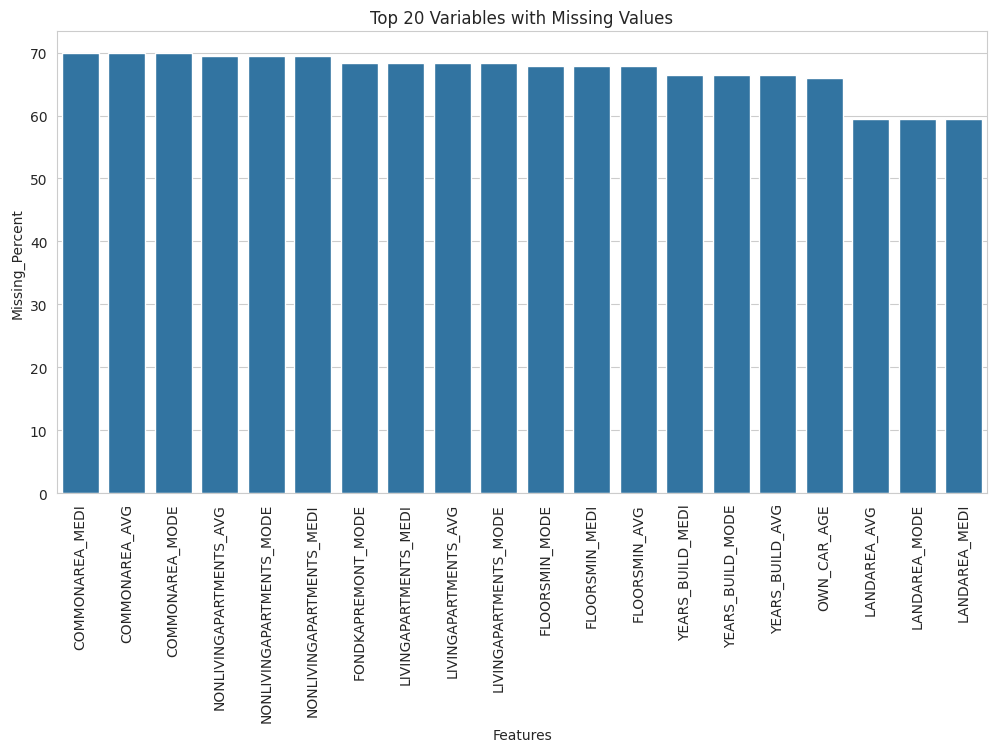

In [54]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_df.head(20).index,
    y=missing_df.head(20)['Missing_Percent']
)

plt.title("Top 20 Variables with Missing Values")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.show()

The following variables have extremely high missing values:

Feature	                          Missing %
COMMONAREA	                       69.87%
NONLIVINGAPARTMENTS	               69.43%
FONDKAPREMONT_MODE	               68.39%
LIVINGAPARTMENTS	               68.35%
FLOORSMIN	                       67.85%
YEARS_BUILD	                       66.50%
OWN_CAR_AGE	                       65.99%

Most highly missing features relate to housing[property] information
This suggests that property details are unavailable for a large proportion of applicants.
This missingness is expected because many customers do not own a car.

In [55]:
df_copy['FLAG_OWN_CAR'].value_counts()

,count
FLAG_OWN_CAR,
N,202924
Y,104587


In [56]:
df_copy['FLAG_OWN_CAR'].value_counts(normalize=True) * 100

,proportion
FLAG_OWN_CAR,
N,65.989184
Y,34.010816


#### Outlier Analysis

Numerical Columns

In [57]:
num_columns = df_copy.select_dtypes(
    include=['int64','float64']
).columns

In [58]:
print(num_columns)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AGE_YEARS'],
      dtype='object', length=107)


Statistical Summary

In [59]:
df_copy[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.000000,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.000000,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.000000,270000.000000,513531.000000,808650.000000,4.050000e+06
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.000000,0.000000,0.000000,0.000000,8.000000e+00
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.000000,0.000000,0.000000,0.000000,2.700000e+01
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.000000,0.000000,0.000000,0.000000,2.610000e+02
AMT_REQ_CREDIT_BUREAU_YEAR,265992.0,1.899974,1.869295,0.000000,0.000000,1.000000,3.000000,2.500000e+01


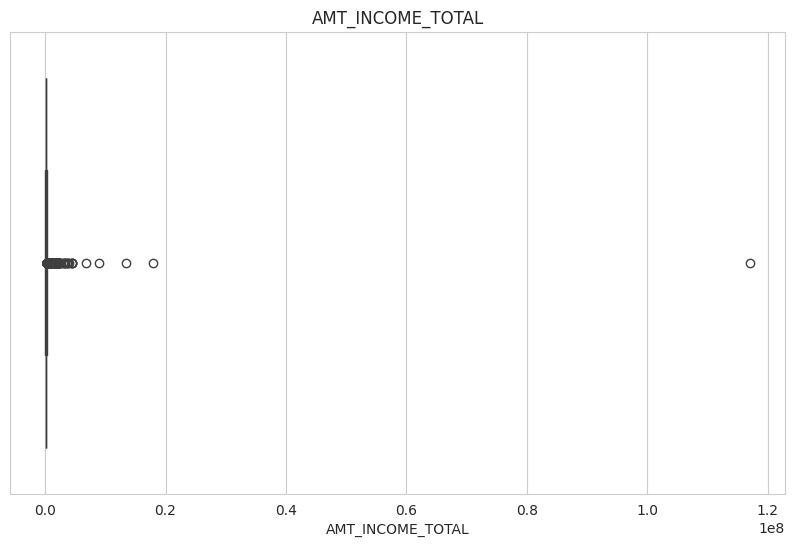

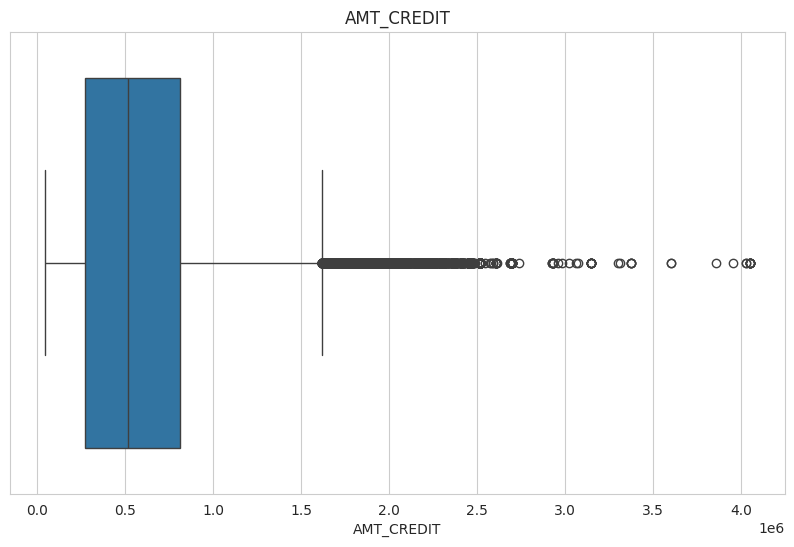

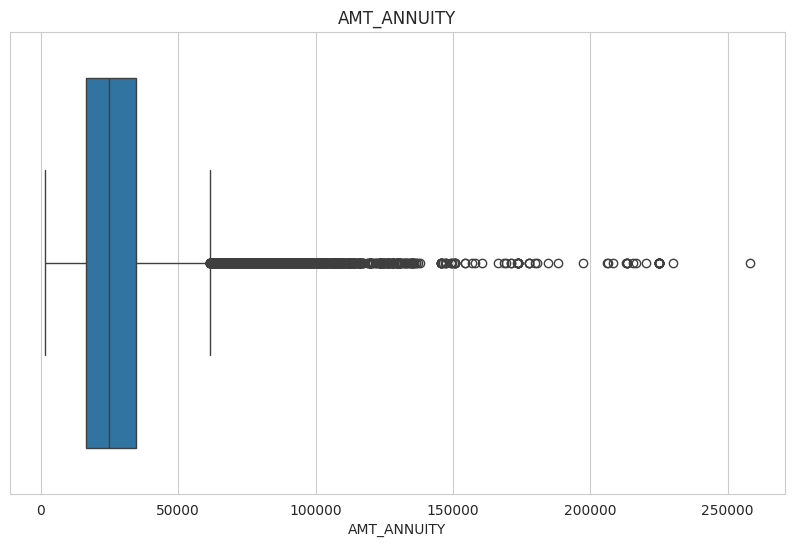

In [60]:
for col in [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY'
]:
    sns.boxplot(
        x=df_copy[col]
    )
    plt.title(col)
    plt.show()

#### IQR Method

Formula ----> IQR = Q3-Q1
Lower Bound = Q1−1.5(IQR)
Upper Bound = Q3+1.5(IQR)

In [61]:
Q1 = df_copy['AMT_INCOME_TOTAL'].quantile(0.25)
Q3 = df_copy['AMT_INCOME_TOTAL'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_copy[
    (df_copy['AMT_INCOME_TOTAL'] < lower) |
    (df_copy['AMT_INCOME_TOTAL'] > upper)
]

Before vs After comparison

In [62]:
df_copy['AMT_INCOME_TOTAL_CAPPED'] = df_copy['AMT_INCOME_TOTAL'].clip(lower, upper)

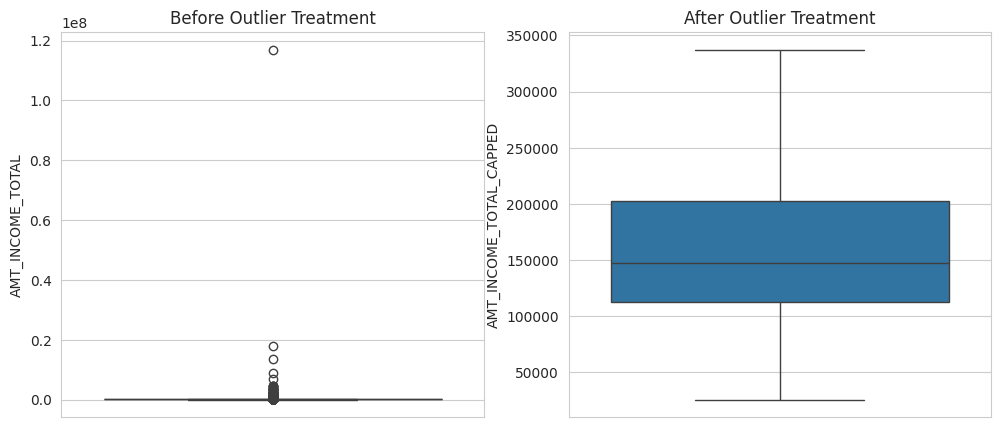

In [63]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df_copy['AMT_INCOME_TOTAL'])
plt.title("Before Outlier Treatment")

plt.subplot(1,2,2)
sns.boxplot(y=df_copy['AMT_INCOME_TOTAL_CAPPED'])  # after treatment column
plt.title("After Outlier Treatment")

plt.show()

A Histogram for showing distribution

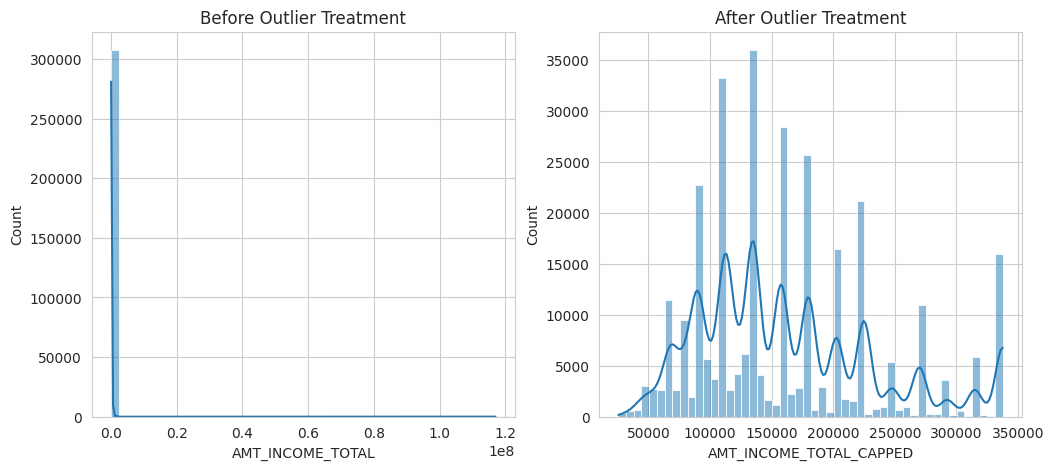

In [64]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_copy['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title("Before Outlier Treatment")

plt.subplot(1,2,2)
sns.histplot(df_copy['AMT_INCOME_TOTAL_CAPPED'], bins=50, kde=True)
plt.title("After Outlier Treatment")

plt.show()

In [65]:
df_copy['AMT_CREDIT_CAPPED'] = df_copy['AMT_CREDIT'].clip(lower, upper)

In [66]:
df_copy['AMT_ANNUITY_CAPPED'] = df_copy['AMT_ANNUITY'].clip(lower, upper)

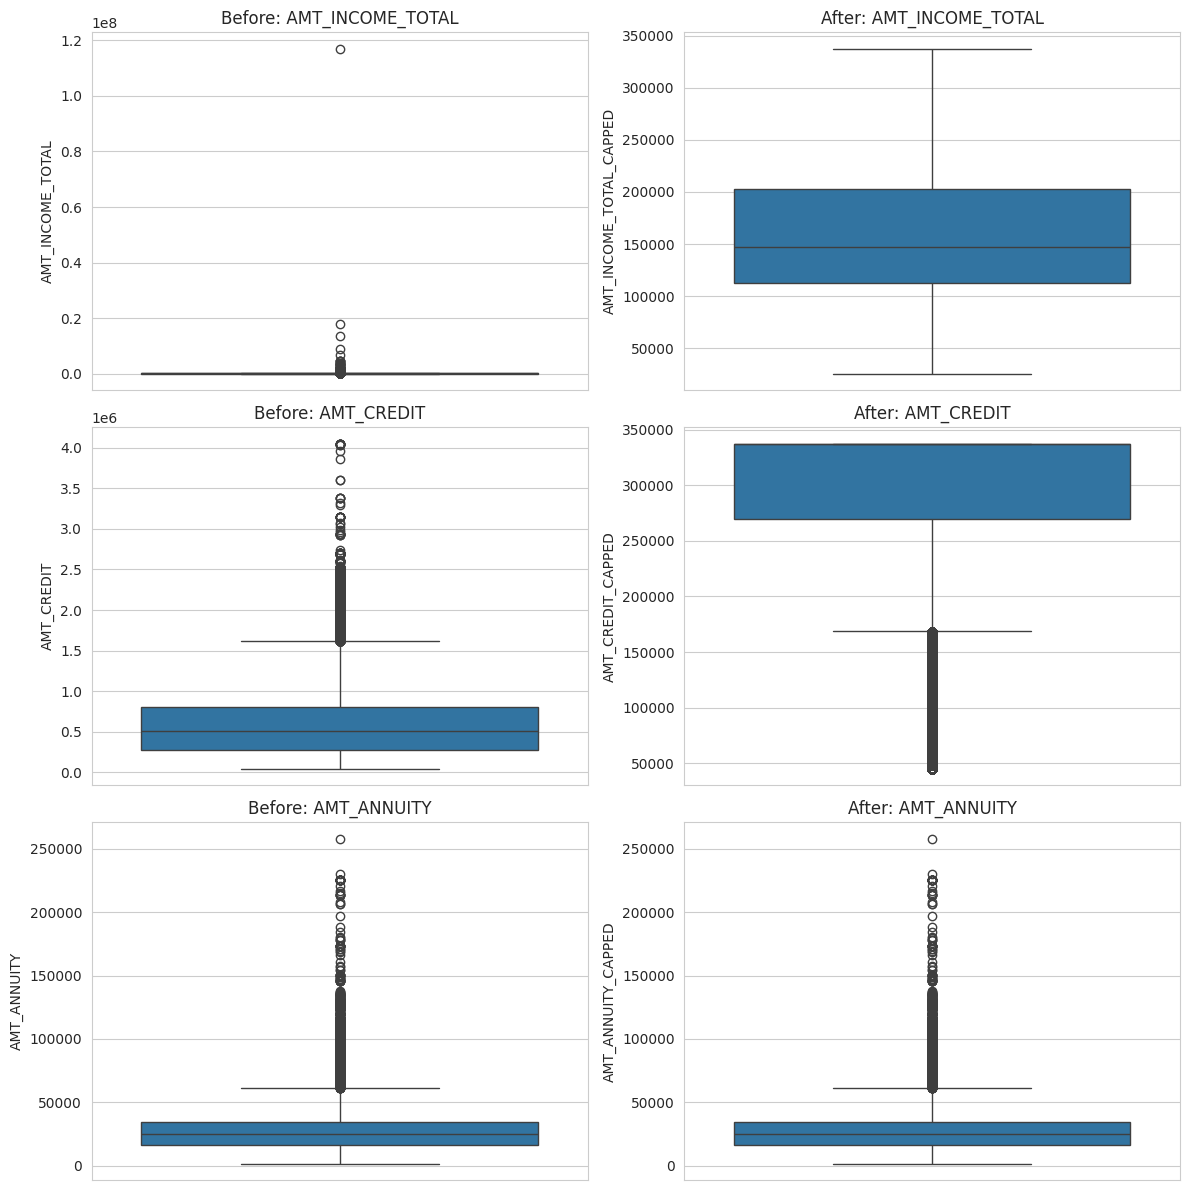

In [67]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

for i, col in enumerate(cols):
    sns.boxplot(y=df_copy[col], ax=axes[i,0])
    axes[i,0].set_title(f"Before: {col}")

    sns.boxplot(y=df_copy[col + '_CAPPED'], ax=axes[i,1])
    axes[i,1].set_title(f"After: {col}")

plt.tight_layout()
plt.show()

Outlier treatment was applied to key financial variables including AMT_INCOME_TOTAL, AMT_CREDIT, and AMT_ANNUITY using IQR-based winsorization. The effectiveness of treatment was validated using before-and-after boxplots, which show a significant reduction in extreme values while preserving the overall data distribution.

Histogram

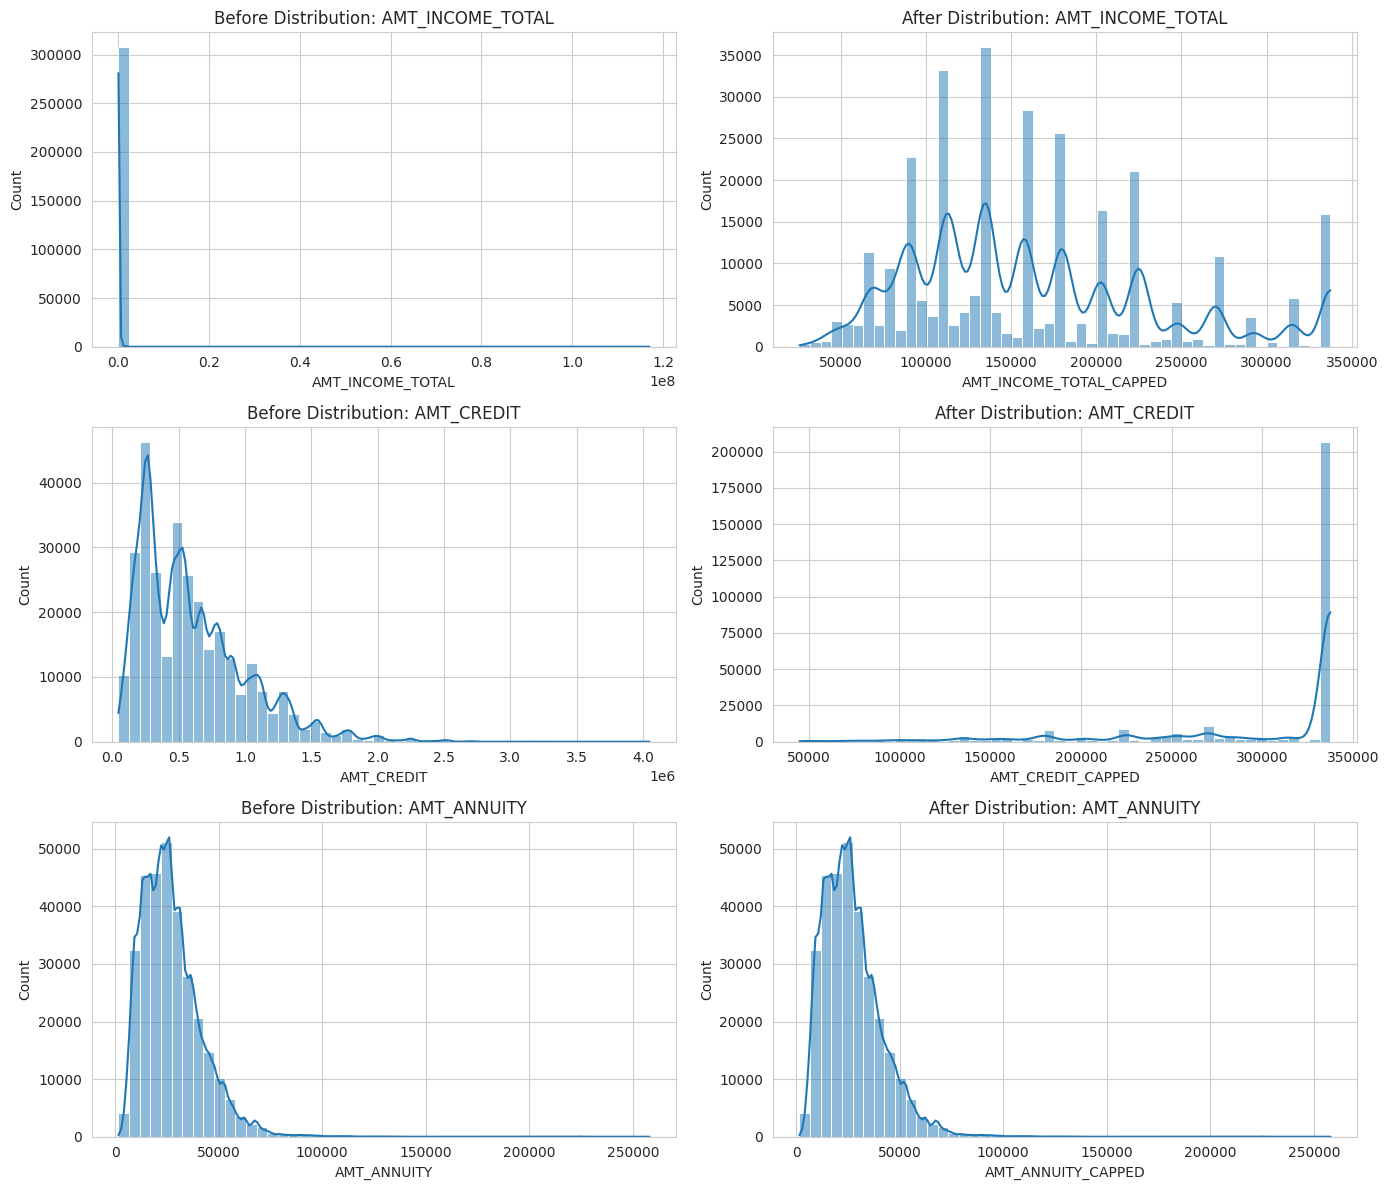

In [68]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(cols):

    # BEFORE
    sns.histplot(df_copy[col], bins=50, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Before Distribution: {col}")

    # AFTER
    sns.histplot(df_copy[col + '_CAPPED'], bins=50, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"After Distribution: {col}")

plt.tight_layout()
plt.show()

##### Feature Engineering

In [69]:
df_copy['SK_ID_CURR'].duplicated().sum()

np.int64(0)

In [70]:
high_missing_cols = missing_percent[
    missing_percent > 65
].index
print(high_missing_cols)

Index(['COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI',
       'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE',
       'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE',
       'FLOORSMIN_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_AVG',
       'YEARS_BUILD_MEDI', 'OWN_CAR_AGE'],
      dtype='object')


Checking whether missingness itself relates to default risk.

In [71]:
for col in high_missing_cols:
    temp = df_copy[col].isnull().astype(int)

    print(
        col,
        df_copy.groupby(temp)['TARGET'].mean()*100
    )

COMMONAREA_AVG COMMONAREA_AVG
0    6.910174
1    8.574221
Name: TARGET, dtype: float64
COMMONAREA_MEDI COMMONAREA_MEDI
0    6.910174
1    8.574221
Name: TARGET, dtype: float64
COMMONAREA_MODE COMMONAREA_MODE
0    6.910174
1    8.574221
Name: TARGET, dtype: float64
NONLIVINGAPARTMENTS_MODE NONLIVINGAPARTMENTS_MODE
0    6.912987
1    8.583512
Name: TARGET, dtype: float64
NONLIVINGAPARTMENTS_MEDI NONLIVINGAPARTMENTS_MEDI
0    6.912987
1    8.583512
Name: TARGET, dtype: float64
NONLIVINGAPARTMENTS_AVG NONLIVINGAPARTMENTS_AVG
0    6.912987
1    8.583512
Name: TARGET, dtype: float64
FONDKAPREMONT_MODE FONDKAPREMONT_MODE
0    6.891870
1    8.618845
Name: TARGET, dtype: float64
LIVINGAPARTMENTS_MEDI LIVINGAPARTMENTS_MEDI
0    6.888154
1    8.621354
Name: TARGET, dtype: float64
LIVINGAPARTMENTS_MODE LIVINGAPARTMENTS_MODE
0    6.888154
1    8.621354
Name: TARGET, dtype: float64
LIVINGAPARTMENTS_AVG LIVINGAPARTMENTS_AVG
0    6.888154
1    8.621354
Name: TARGET, dtype: float64
FLOORSMIN_AVG FLOORS

"0" --- means not missing
"1" --- means missing values
The missing values are not random
Applicants with missing housing[property] information tend to default more frequently.

creates new binary indicator columns that record whether the original value was missing or not.

In [72]:
for col in high_missing_cols:
    df_copy[col + '_MISSING'] = (
        df_copy[col].isnull().astype(int)
    )

In [73]:
df_copy.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,LIVINGAPARTMENTS_MEDI_MISSING,LIVINGAPARTMENTS_MODE_MISSING,LIVINGAPARTMENTS_AVG_MISSING,FLOORSMIN_AVG_MISSING,FLOORSMIN_MODE_MISSING,FLOORSMIN_MEDI_MISSING,YEARS_BUILD_MODE_MISSING,YEARS_BUILD_AVG_MISSING,YEARS_BUILD_MEDI_MISSING,OWN_CAR_AGE_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0,0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0,0,0,0,0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1,1,1,1,1,1,1,1,1,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1,1,1,1,1,1,1,1,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1,1,1,1,1,1,1,1,1,1


In [74]:
print(df_copy[['OWN_CAR_AGE',
               'OWN_CAR_AGE_MISSING']].head())

   OWN_CAR_AGE  OWN_CAR_AGE_MISSING
0          NaN                    1
1          NaN                    1
2         26.0                    0
3          NaN                    1
4          NaN                    1


In [75]:
print(df_copy.shape)
print(final_df.shape)

(307511, 143)
(307511, 150)


In [76]:
print(df_copy.index.equals(final_df.index))

True


In [77]:
final_df = final_df.join(
    df_copy[[col for col in df_copy.columns if col.endswith('_MISSING')]]
)

In [78]:
final_df.filter(like='_MISSING').head()

,COMMONAREA_AVG_MISSING,COMMONAREA_MEDI_MISSING,COMMONAREA_MODE_MISSING,NONLIVINGAPARTMENTS_MODE_MISSING,NONLIVINGAPARTMENTS_MEDI_MISSING,NONLIVINGAPARTMENTS_AVG_MISSING,FONDKAPREMONT_MODE_MISSING,LIVINGAPARTMENTS_MEDI_MISSING,LIVINGAPARTMENTS_MODE_MISSING,LIVINGAPARTMENTS_AVG_MISSING,FLOORSMIN_AVG_MISSING,FLOORSMIN_MODE_MISSING,FLOORSMIN_MEDI_MISSING,YEARS_BUILD_MODE_MISSING,YEARS_BUILD_AVG_MISSING,YEARS_BUILD_MEDI_MISSING,OWN_CAR_AGE_MISSING
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [79]:
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,LIVINGAPARTMENTS_MEDI_MISSING,LIVINGAPARTMENTS_MODE_MISSING,LIVINGAPARTMENTS_AVG_MISSING,FLOORSMIN_AVG_MISSING,FLOORSMIN_MODE_MISSING,FLOORSMIN_MEDI_MISSING,YEARS_BUILD_MODE_MISSING,YEARS_BUILD_AVG_MISSING,YEARS_BUILD_MEDI_MISSING,OWN_CAR_AGE_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0,0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0,0,0,0,0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1,1,1,1,1,1,1,1,1,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1,1,1,1,1,1,1,1,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1,1,1,1,1,1,1,1,1,1


Performed feature engineering by creating missing indicator variables for high-missing-value features. This was based on EDA findings that missingness was correlated with the target variable, indicating informative missingness. These features were then included in the final dataset for modeling "final_df"

##### preprocessing

In [80]:
df_model = final_df.copy()

In [81]:
df_model.shape

(307511, 167)

Encoding categorical variables -- One-hot encoding

In [82]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [83]:
df_model.shape

(307511, 275)

In [84]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 275 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_Yes
dtypes: bool(124), float64(93), int64(58)
memory usage: 390.6 MB


In [85]:
target_corr = df_model.corr()['TARGET'].sort_values(ascending=False)
print(target_corr)

TARGET                                  1.000000
CC_BALANCE_MEAN                         0.087106
DAYS_BIRTH                              0.078239
CC_BALANCE_MAX                          0.068830
REGION_RATING_CLIENT_W_CITY             0.060893
                                          ...   
NAME_EDUCATION_TYPE_Higher education   -0.056593
AVG_BB_MONTHS                          -0.080193
EXT_SOURCE_1                           -0.155317
EXT_SOURCE_2                           -0.160472
EXT_SOURCE_3                           -0.178919
Name: TARGET, Length: 275, dtype: float64


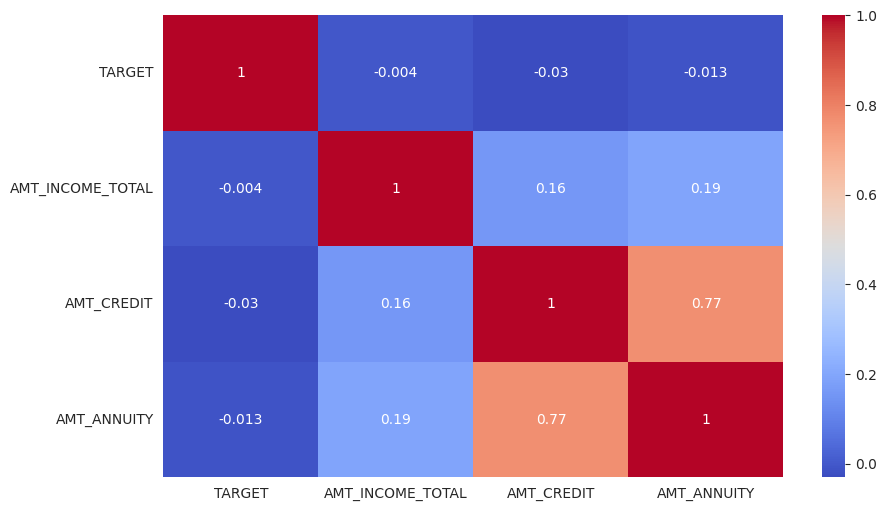

In [86]:
corr = df_copy[
    ['TARGET',
     'AMT_INCOME_TOTAL',
     'AMT_CREDIT',
     'AMT_ANNUITY']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

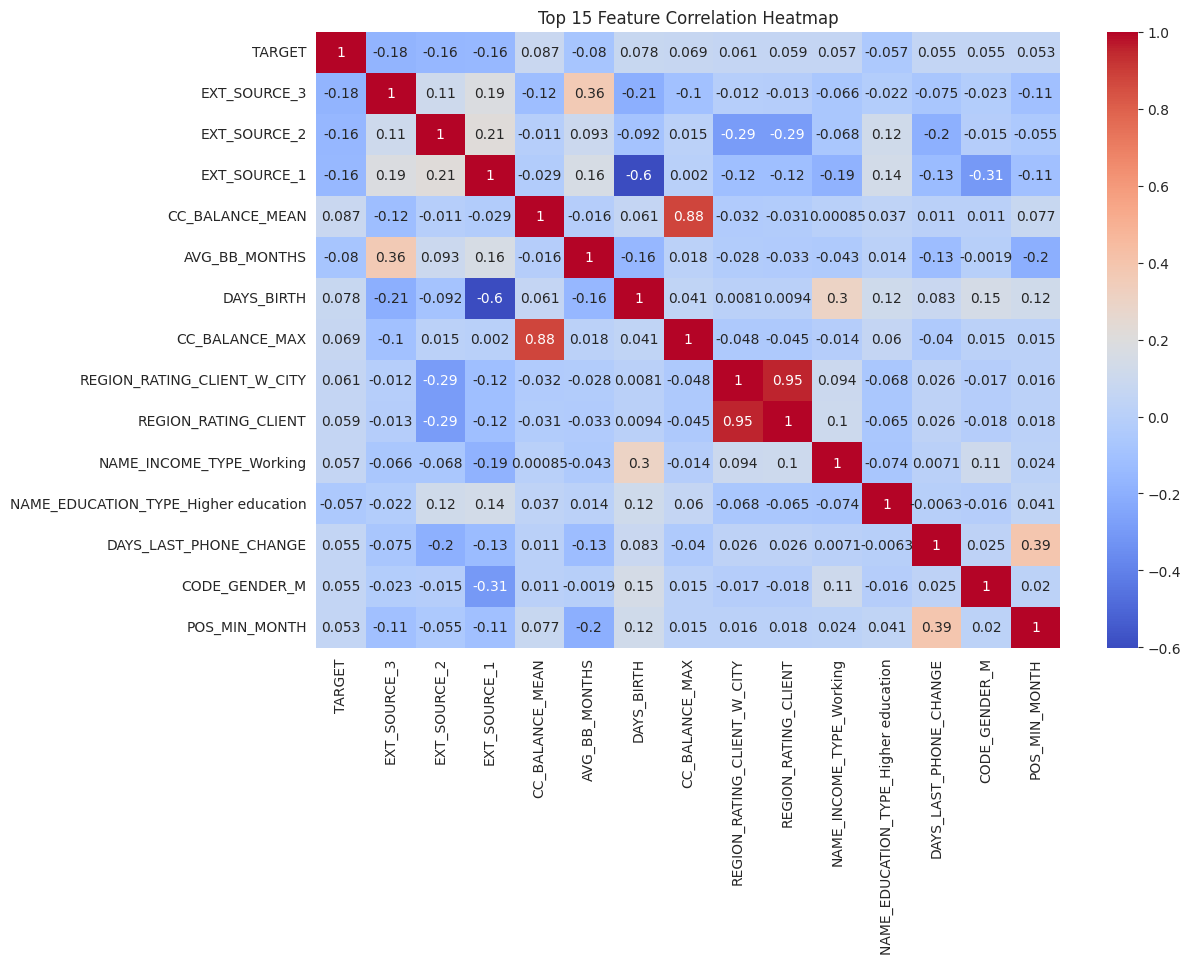

In [87]:
top_features = target_corr.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,8))
sns.heatmap(df_model[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top 15 Feature Correlation Heatmap")
plt.show()

Spliting the data set

In [88]:
X = df_model.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_model['TARGET']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

Feature scaling (IMPORTANT for Logistic Regression)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
model = LogisticRegression(max_iter=1000,
    class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Logistic Regression does not handle missing values, so I applied median imputation after train-test split to avoid data leakage. After imputation, I standardized the features before training the model.

In [95]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7592090831298235
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503



After applying class_weight='balanced', the model significantly improved recall for the minority class from 2% to 70%, meaning it now captures most defaulters. However, this came at the cost of lower precision due to increased false positives. The ROC-AUC remained stable at 0.759, indicating that the model’s ranking ability did not change, but the decision threshold behavior improved.

We used logistic regression as a baseline model because it is highly interpretable and widely used in credit risk modeling.

In [96]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[39455 17083]
 [ 1542  3423]]


The confusion matrix shows that the model correctly identifies 39455 defaulters but also produces number of false positives (1542). This results in a high recall of 70%, meaning most defaulters are detected, which is critical in credit risk. However, precision is low due to over-flagging of non-defaulters.

#### Decision Tree

In [97]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [98]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

ROC-AUC: 0.7115640357311039


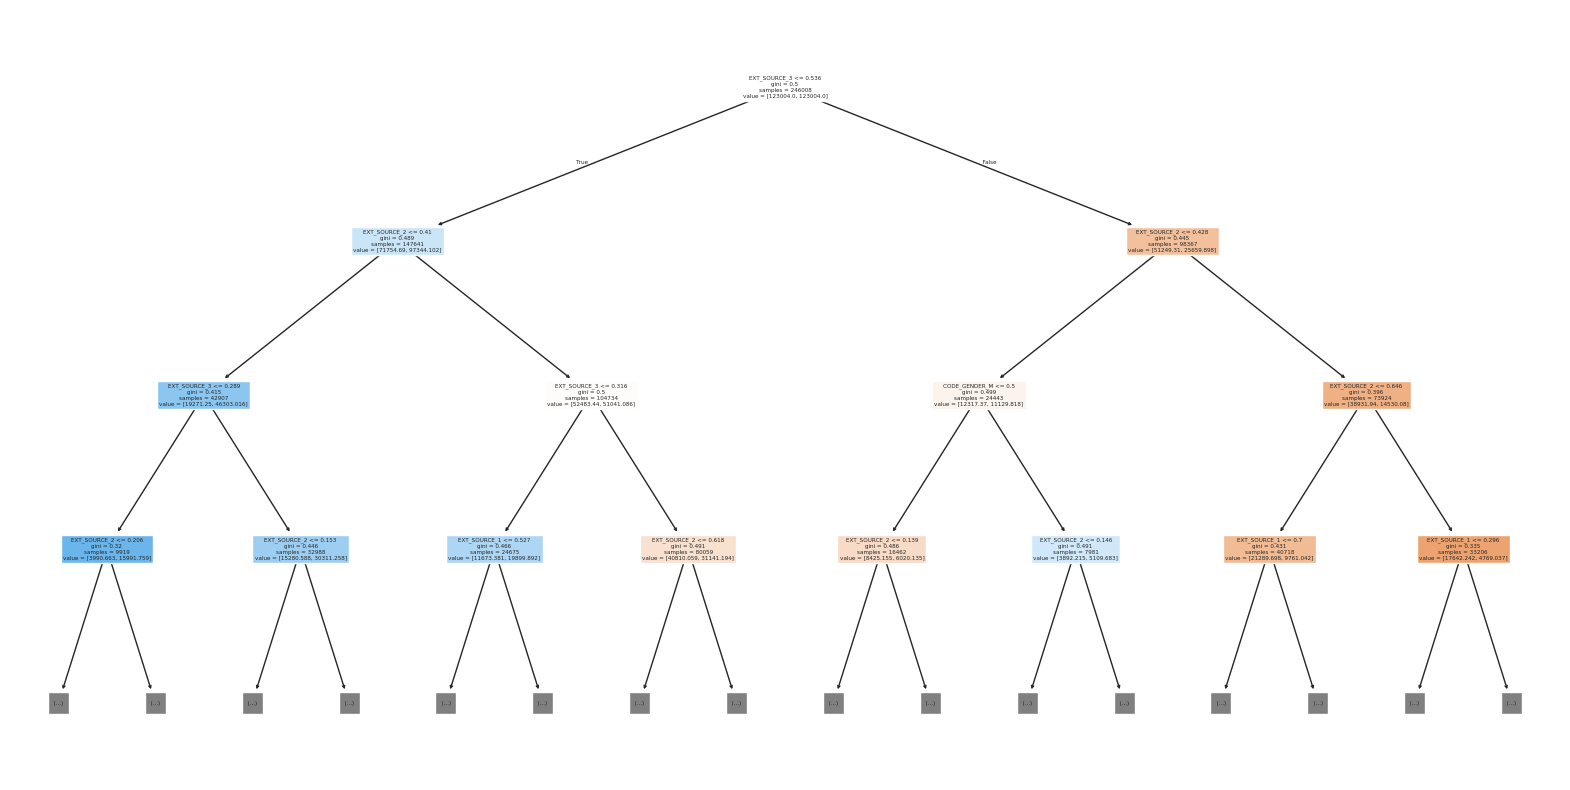

In [99]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, filled=True, max_depth=3)
plt.show()

- After modeling a logistic regression baseline, I trained a decision tree to capture non-linear relationships and understand feature interactions. Although single trees tend to overfit, they provide valuable interpretability and feature importance insights.
- Logistic Regression is performing better, and relationships are somewhat linear.[Given data is somewhat linear]
- A single tree is a weak learner.
- The tree struggles to split effectively.
- The decision tree is biased towards the majority class.

**Random Forest**

In [100]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 15, 20, None],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

In [101]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
0.7492917644080789


In [118]:
best_rf = random_search.best_estimator_

y_prob_rf = best_rf.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(y_test, y_prob)
)

0.7520307474761336


In [108]:
from sklearn.metrics import classification_report

y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.43      0.01      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503



After hyperparameter tuning, the Random Forest model improved its ROC-AUC from 0.73 to 0.752, indicating better generalization. However, it still underperformed compared to Logistic Regression (0.759), suggesting that the underlying relationships in the data are better captured by a linear model rather than complex non-linear model.

In [109]:
!pip install xgboost

#### XGBOOST

In [110]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [111]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [112]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

In [113]:
roc_auc = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.771899429580946


In [114]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.53      0.04      0.07      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.52      0.51     61503
weighted avg       0.89      0.92      0.89     61503



In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

[[56372   166]
 [ 4780   185]]


Model performance summary

| Model               |   ROC-AUC | Interpretation                                          |
| ------------------- | --------: | ------------------------------------------------------- |
| Logistic Regression | **0.759** | Strong, stable baseline model                           |
| Decision Tree       |     0.711 | Weak performance, high variance, overfitting tendency   |
| Random Forest       |     0.752 | Improved over single tree
| XGBoost             | **0.771** | Best performing model, captures complex patterns        |


The dataset shows relatively strong linear patterns, as Logistic Regression performs better. However, XGBoost provides the best predictive performance with a ROC-AUC of 0.771, making it the most suitable model for final deployment. Tree-based models improve progressively from Decision Tree to Random Forest, but XGBoost outperforms the linear baseline

We evaluated four models for credit risk prediction. XGBoost achieved the highest ROC-AUC of 0.771, followed closely by Logistic Regression at 0.759, indicating strong linear structure in the data. Decision Tree and Random Forest performed lower, This suggests that model complexity alone does not ensure better performance in the absence of strong predictive signal in the features.

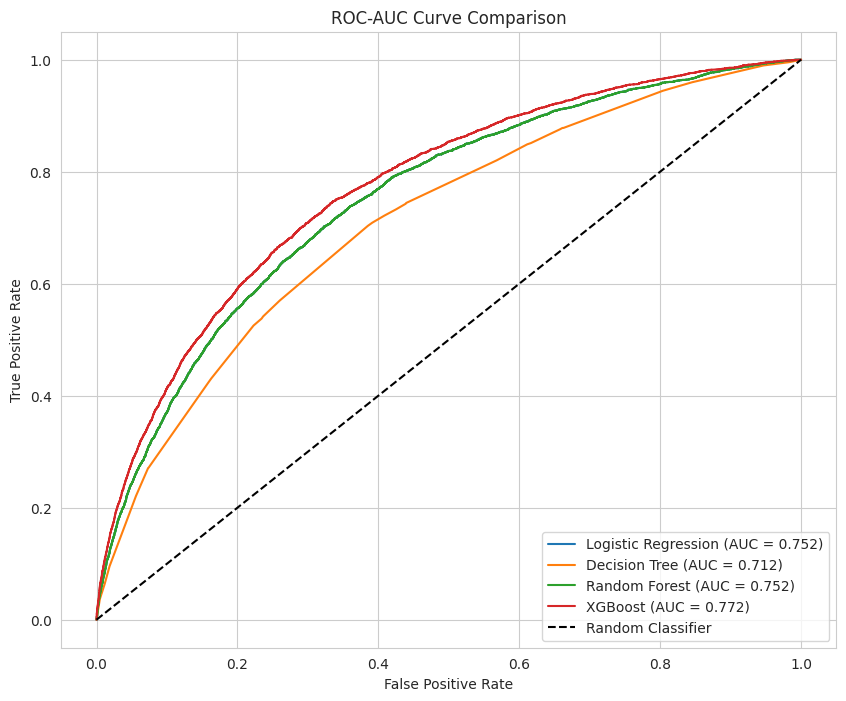

In [119]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = auc(fpr_lr, tpr_lr)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC = {auc_dt:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='black',
         label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()